# Leave-one-landscape-out learned depth policies

This notebook evaluates the seven 100-trial-block schedules learned from the fixed-depth improvement analysis. Each learned policy is compared with every complete policy in `09_big_experiment`.

In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)

HERE = Path.cwd()
if not (HERE / 'loo_depth_policies.json').exists():
    HERE = Path('experiments/synthaticBench/o1_deterministic/depth_policies/09_02_new policies').resolve()
BIG_DIR = HERE.parent / '09_big_experiment'
BASELINE_OUTPUT = BIG_DIR / 'smac_output'
LEARNED_OUTPUT = HERE / 'smac_output'
INDIVIDUAL_OUTPUT = HERE / 'smac_output_individual_landscape'
BENCHMARK_SEEDS = tuple(range(40, 47))
SMAC_SEEDS = tuple(range(10))
N_TRIALS = 1000
manifest = json.loads((HERE / 'loo_depth_policies.json').read_text())
individual_manifest = json.loads(
    (HERE / 'individual_landscape_depth_policies.json').read_text()
)

## Data loading and completeness

Only complete 1,000-trial trajectories are used. A baseline policy must contain all 7 landscapes x 10 SMAC seeds. The learned-policy data must contain all 7 learned policies x 7 evaluation landscapes x 10 SMAC seeds.

In [8]:
def load_trajectories(root, source):
    rows = []
    malformed = []
    for path in sorted(root.rglob('trajectory.json')):
        try:
            data = json.loads(path.read_text())
            best_regret = np.asarray(data['best_regret'], dtype=float)
            if len(best_regret) != N_TRIALS or not np.all(np.isfinite(best_regret)):
                malformed.append((path, f'{len(best_regret)} valid trials'))
                continue
            spec = data.get('policy_spec') or {}
            rows.append({
                'source': source,
                'policy': data['policy'],
                'policy_family': data.get('policy_family', 'unknown'),
                'policy_type': data.get('policy_type', 'unknown'),
                'is_adaptive': data.get('policy_type') != 'fixed',
                'benchmark_seed': int(data['benchmark_seed']),
                'smac_seed': int(data['smac_seed']),
                'held_out_landscape': data.get('selection_held_out_landscape'),
                'selection_landscape': data.get('selection_landscape'),
                'selection_is_in_sample': data.get('selection_is_in_sample'),
                'fixed_depth': spec.get('fixed_depth'),
                'final_regret': float(best_regret[-1]),
                'best_regret': best_regret,
                'path': str(path),
            })
        except (KeyError, ValueError, TypeError, json.JSONDecodeError) as error:
            malformed.append((path, str(error)))
    return pd.DataFrame(rows), malformed

baseline_raw, baseline_malformed = load_trajectories(BASELINE_OUTPUT, '09_big_experiment')
learned, learned_malformed = load_trajectories(LEARNED_OUTPUT, 'learned_loo')
individual, individual_malformed = load_trajectories(
    INDIVIDUAL_OUTPUT, 'individual_landscape'
)

expected_pairs = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS)
baseline_counts = (baseline_raw[['policy', 'benchmark_seed', 'smac_seed']]
                   .drop_duplicates().groupby('policy').size())
complete_baseline_policies = baseline_counts[baseline_counts == expected_pairs].index
baseline = baseline_raw[baseline_raw.policy.isin(complete_baseline_policies)].copy()
if baseline.duplicated(['policy', 'benchmark_seed', 'smac_seed']).any():
    raise RuntimeError('Duplicate complete baseline trajectories found.')

expected_learned = {
    (held_out, benchmark_seed, smac_seed)
    for held_out in BENCHMARK_SEEDS
    for benchmark_seed in BENCHMARK_SEEDS
    for smac_seed in SMAC_SEEDS
}
actual_learned = {
    (int(row.held_out_landscape), int(row.benchmark_seed), int(row.smac_seed))
    for row in learned.itertuples()
}
missing_learned = sorted(expected_learned - actual_learned)
extra_learned = sorted(actual_learned - expected_learned)
expected_individual = {
    (landscape_seed, smac_seed)
    for landscape_seed in BENCHMARK_SEEDS
    for smac_seed in SMAC_SEEDS
}
actual_individual = set() if individual.empty else {
    (int(row.selection_landscape), int(row.smac_seed))
    for row in individual.itertuples()
}
missing_individual = sorted(expected_individual - actual_individual)
extra_individual = sorted(actual_individual - expected_individual)

print(f'Complete baseline policies: {len(complete_baseline_policies)} ({len(baseline)} trajectories)')
print(f'Learned-policy trajectories: {len(learned)} / {len(expected_learned)}')
print(f'Individual in-sample trajectories: {len(individual)} / {len(expected_individual)}')
print(
    'Malformed baseline/LOO/in-sample files: '
    f'{len(baseline_malformed)} / {len(learned_malformed)} / '
    f'{len(individual_malformed)}'
)
if missing_learned:
    print('First missing learned runs:', missing_learned[:10])
if extra_learned:
    print('Unexpected learned runs:', extra_learned[:10])
if missing_individual:
    print('First missing in-sample runs:', missing_individual[:10])
if extra_individual:
    print('Unexpected in-sample runs:', extra_individual[:10])
if len(complete_baseline_policies) < 109:
    raise RuntimeError('Fewer than the 109 original baseline policies are complete.')
if missing_learned or extra_learned or learned_malformed:
    raise RuntimeError('Learned-policy experiment is not complete and clean yet.')
if extra_individual or individual_malformed:
    raise RuntimeError('In-sample policy outputs contain unexpected or malformed runs.')

Complete baseline policies: 110 (7700 trajectories)
Learned-policy trajectories: 490 / 490
Individual in-sample trajectories: 70 / 70
Malformed baseline/LOO/in-sample files: 0 / 0 / 0


## Learned schedules

,1-100,101-200,201-300,301-400,401-500,501-600,601-700,701-800,801-900,901-1000
held-out landscape,,,,,,,,,,
40,5,9,12,13,11,16,17,20,19,20
41,5,9,12,13,15,11,17,20,19,20
42,5,7,10,13,15,11,17,20,19,20
43,5,9,16,13,11,13,17,20,17,20
44,6,9,12,12,13,11,17,20,17,20
45,5,9,10,13,14,11,17,20,18,20
46,5,9,10,13,15,11,17,20,19,20


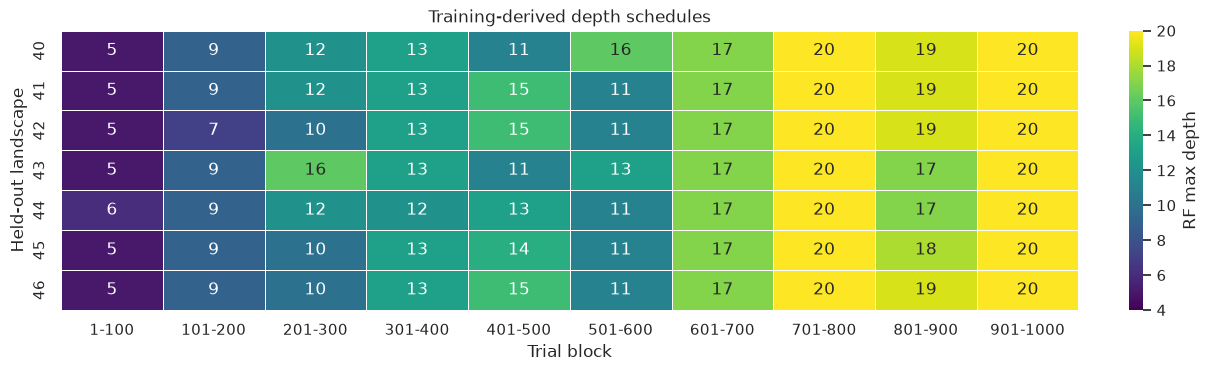

In [9]:
schedule_df = pd.DataFrame(
    [item['block_depths'] for item in manifest['policies']],
    index=[item['held_out_landscape'] for item in manifest['policies']],
    columns=[f'{start + 1}-{start + 100}' for start in manifest['block_start_trials']],
)
schedule_df.index.name = 'held-out landscape'
display(schedule_df)

fig, ax = plt.subplots(figsize=(12, 3.6), constrained_layout=True)
sns.heatmap(schedule_df, annot=True, fmt='d', cmap='viridis', vmin=4, vmax=20,
            linewidths=.5, cbar_kws={'label': 'RF max depth'}, ax=ax)
ax.set_xlabel('Trial block')
ax.set_ylabel('Held-out landscape')
ax.set_title('Training-derived depth schedules')
plt.show()

## Pooled training and held-out ranks

For a policy learned with landscape $h$ held out, its **training score** is one mean over all 60 final regrets from the other six landscapes (6 landscapes x 10 SMAC seeds). Every baseline receives the same pooled score, and the learned policy is ranked among those baselines. Thus, these are joint six-landscape ranks, not means of six landscape-specific ranks.

The **held-out score** is the mean final regret over the 10 SMAC seeds on landscape $h$. `LOO best fixed` is selected by pooled training score. `Oracle fixed` is selected on the held-out landscape and is therefore an optimistic descriptive reference, not a fair generalization estimate.

In [10]:
fixed_policy_depth = (baseline.dropna(subset=['fixed_depth'])[['policy', 'fixed_depth']]
                      .drop_duplicates().set_index('policy')['fixed_depth'].astype(int))
if set(fixed_policy_depth) != set(range(4, 21)):
    raise RuntimeError(f'Expected fixed depths 4..20, found {sorted(set(fixed_policy_depth))}.')

baseline_landscape_policy = (
    baseline.groupby(
        ['benchmark_seed', 'policy', 'policy_family', 'policy_type', 'is_adaptive'],
        as_index=False,
    ).agg(mean_final_regret=('final_regret', 'mean'))
)

ranking_rows = []
box_rows = []
for held_out in BENCHMARK_SEEDS:
    training_landscapes = [seed for seed in BENCHMARK_SEEDS if seed != held_out]
    learned_name = f'loo_block_depth_heldout_{held_out}'
    learned_split = learned[learned.held_out_landscape == held_out]

    baseline_training = (baseline[baseline.benchmark_seed.isin(training_landscapes)]
                         .groupby('policy').final_regret.mean())
    learned_training_score = learned_split[
        learned_split.benchmark_seed.isin(training_landscapes)
    ].final_regret.mean()
    training_scores = pd.concat([
        baseline_training,
        pd.Series({learned_name: learned_training_score}),
    ])
    training_ranks = training_scores.rank(method='min', ascending=True)

    baseline_heldout = (baseline[baseline.benchmark_seed == held_out]
                        .groupby('policy').final_regret.mean())
    learned_heldout_score = learned_split[
        learned_split.benchmark_seed == held_out
    ].final_regret.mean()
    heldout_scores = pd.concat([
        baseline_heldout,
        pd.Series({learned_name: learned_heldout_score}),
    ])
    heldout_ranks = heldout_scores.rank(method='min', ascending=True)

    fixed_training = baseline_training[baseline_training.index.isin(fixed_policy_depth.index)]
    loo_fixed_policy = fixed_training.idxmin()
    oracle_fixed_scores = baseline_heldout[baseline_heldout.index.isin(fixed_policy_depth.index)]
    oracle_fixed_policy = oracle_fixed_scores.idxmin()
    loo_depth = int(fixed_policy_depth[loo_fixed_policy])
    oracle_depth = int(fixed_policy_depth[oracle_fixed_policy])

    adaptive_training = baseline_landscape_policy.query(
        'benchmark_seed != @held_out and is_adaptive'
    ).copy()
    adaptive_training['training_landscape_rank'] = (
        adaptive_training.groupby('benchmark_seed')['mean_final_regret']
        .rank(method='average')
    )
    adaptive_ranked = (
        adaptive_training.groupby('policy', as_index=False)
        .agg(
            mean_training_rank=('training_landscape_rank', 'mean'),
            mean_training_regret=('mean_final_regret', 'mean'),
        )
        .sort_values(['mean_training_rank', 'mean_training_regret', 'policy'])
    )
    selected_adaptive = {
        top_n: adaptive_ranked.head(top_n).policy.tolist()
        for top_n in (1, 3, 5)
    }

    learned_test = (learned_split[learned_split.benchmark_seed == held_out]
                    .set_index('smac_seed').final_regret.sort_index())
    loo_fixed_test = (baseline[(baseline.benchmark_seed == held_out) &
                               (baseline.policy == loo_fixed_policy)]
                      .set_index('smac_seed').final_regret.sort_index())
    oracle_test = (baseline[(baseline.benchmark_seed == held_out) &
                            (baseline.policy == oracle_fixed_policy)]
                   .set_index('smac_seed').final_regret.sort_index())
    if not learned_test.index.equals(loo_fixed_test.index):
        raise RuntimeError(f'Unpaired held-out SMAC seeds for landscape {held_out}.')

    adaptive_portfolios = {}
    heldout_baseline_runs = baseline[baseline.benchmark_seed == held_out]
    for top_n, selected_policies in selected_adaptive.items():
        portfolio = (
            heldout_baseline_runs[
                heldout_baseline_runs.policy.isin(selected_policies)
            ]
            .groupby('smac_seed').final_regret.mean().sort_index()
        )
        if not portfolio.index.equals(learned_test.index):
            raise RuntimeError(
                f'Unpaired Top-{top_n} portfolio seeds for landscape {held_out}.'
            )
        adaptive_portfolios[top_n] = portfolio

    ranking_rows.append({
        'held_out': held_out,
        'training_rank': int(training_ranks[learned_name]),
        'heldout_rank': int(heldout_ranks[learned_name]),
        'policies_ranked': len(training_scores),
        'training_mean_regret': learned_training_score,
        'heldout_mean_regret': learned_heldout_score,
        'loo_best_fixed_depth': loo_depth,
        'oracle_fixed_depth': oracle_depth,
        'learned_win_rate_vs_loo_fixed': float((learned_test < loo_fixed_test).mean()),
        'median_regret_ratio_vs_loo_fixed': float(np.median(learned_test / loo_fixed_test)),
    })
    for strategy, values in [
        ('Learned schedule', learned_test),
        ('Top-1 LOO adaptive', adaptive_portfolios[1]),
        ('Top-3 LOO portfolio', adaptive_portfolios[3]),
        ('Top-5 LOO portfolio', adaptive_portfolios[5]),
        ('LOO best fixed', loo_fixed_test),
        ('Oracle fixed', oracle_test),
    ]:
        for smac_seed, final_regret in values.items():
            box_rows.append({
                'held_out': held_out, 'strategy': strategy,
                'smac_seed': smac_seed, 'final_regret': final_regret,
            })

rankings = pd.DataFrame(ranking_rows)
box_data = pd.DataFrame(box_rows)
display(rankings.style.format({
    'training_mean_regret': '{:.3g}',
    'heldout_mean_regret': '{:.3g}',
    'learned_win_rate_vs_loo_fixed': '{:.0%}',
    'median_regret_ratio_vs_loo_fixed': '{:.3f}',
}))

,held_out,training_rank,heldout_rank,policies_ranked,training_mean_regret,heldout_mean_regret,loo_best_fixed_depth,oracle_fixed_depth,learned_win_rate_vs_loo_fixed,median_regret_ratio_vs_loo_fixed
0,40,35,24,111,4.69e+03,4.32e+03,17,20,60%,0.855
1,41,42,19,111,5.06e+03,2.75e+03,18,19,50%,1.127
2,42,30,46,111,4.48e+03,5.73e+03,19,18,60%,0.952
3,43,51,43,111,5.05e+03,5.14e+03,18,19,50%,1.155
4,44,33,70,111,4.24e+03,8.53e+03,20,17,40%,1.097
5,45,48,48,111,4.98e+03,4.98e+03,18,16,40%,1.057
6,46,57,18,111,5.44e+03,2.52e+03,20,18,50%,0.939


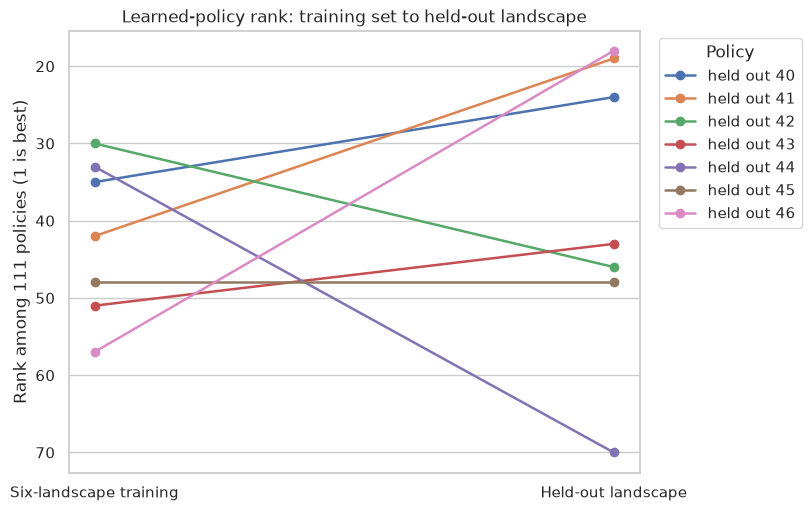

In [11]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for row in rankings.itertuples():
    ax.plot(['Six-landscape training', 'Held-out landscape'],
            [row.training_rank, row.heldout_rank], marker='o', linewidth=1.8,
            label=f'held out {row.held_out}')
ax.invert_yaxis()
ax.set_ylabel(f'Rank among {rankings.policies_ranked.iloc[0]} policies (1 is best)')
ax.set_title('Learned-policy rank: training set to held-out landscape')
ax.legend(title='Policy', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
ax.grid(axis='x', visible=False)
plt.show()

## Held-out final regret

All panels use the same logarithmic y-axis, so spread is visually comparable across landscapes. Points are the ten paired SMAC seeds. `Top-1 LOO adaptive` is the best adaptive policy selected by mean within-landscape rank on the other six landscapes. The Top-3 and Top-5 boxes are SMAC-seed-matched mean portfolios of the best three or five adaptive policies selected by the same rule. The oracle box is intentionally optimistic because its depth was chosen on these same held-out observations.

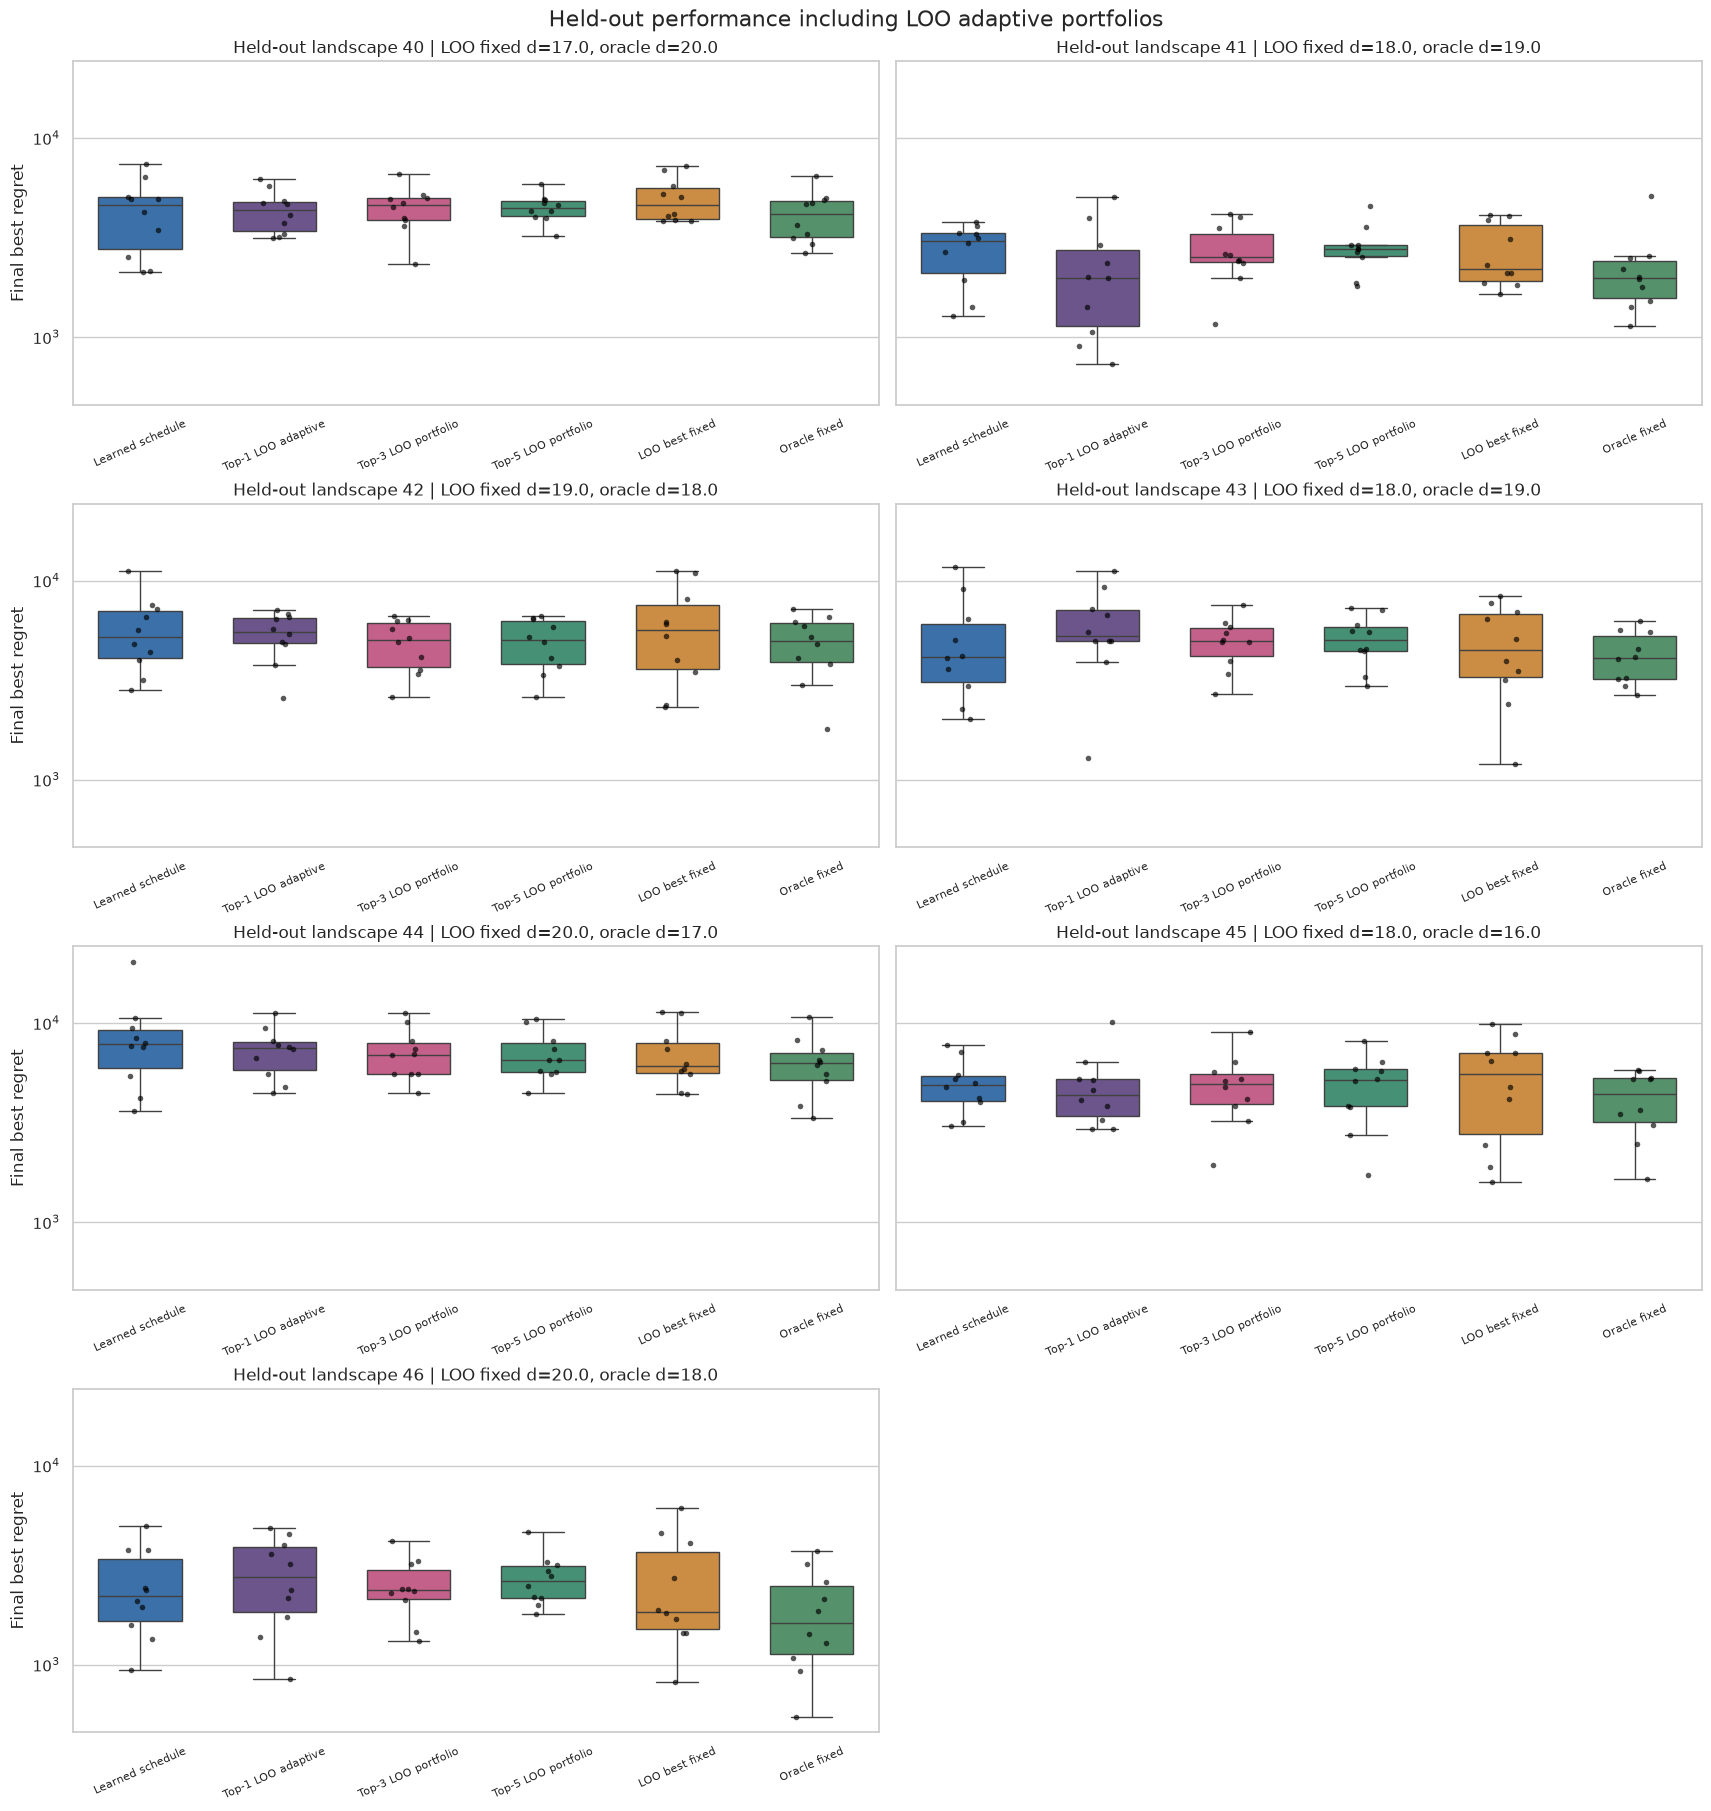

In [12]:
order = [
    'Learned schedule', 'Top-1 LOO adaptive', 'Top-3 LOO portfolio',
    'Top-5 LOO portfolio', 'LOO best fixed', 'Oracle fixed',
]
palette = {
    'Learned schedule': '#2a6fbb',
    'Top-1 LOO adaptive': '#6a4c93',
    'Top-3 LOO portfolio': '#d45087',
    'Top-5 LOO portfolio': '#3a9d78',
    'LOO best fixed': '#e28e2c',
    'Oracle fixed': '#4b9b68',
}
fig, axes = plt.subplots(4, 2, figsize=(17, 18), sharey=True, constrained_layout=True)
for ax, held_out in zip(axes.flat, BENCHMARK_SEEDS):
    sub = box_data[box_data.held_out == held_out]
    selection = rankings[rankings.held_out == held_out].iloc[0]
    sns.boxplot(data=sub, x='strategy', y='final_regret', order=order,
                hue='strategy', hue_order=order, palette=palette,
                width=.62, showfliers=False, legend=False, ax=ax)
    sns.stripplot(data=sub, x='strategy', y='final_regret', order=order,
                  color='black', alpha=.65, size=4, jitter=.14, ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Final best regret')
    ax.set_title(
        f'Held-out landscape {held_out} | LOO fixed d={selection.loo_best_fixed_depth}, '
        f'oracle d={selection.oracle_fixed_depth}'
    )
    ax.tick_params(axis='x', rotation=24, labelsize=8)
axes.flat[-1].axis('off')
fig.suptitle(
    'Held-out performance including LOO adaptive portfolios', fontsize=16
)
plt.show()

## Reading the result

The primary generalization evidence is the held-out rank together with the learned-versus-LOO-fixed paired comparison. A strong training rank followed by a weak held-out rank is evidence that the per-block schedule has overfit the six training landscapes. The oracle fixed depth is useful for showing remaining headroom, but not for deciding whether the learned schedule generalizes.

## In-sample landscape-specific policies

Each policy in this section was constructed from the fixed-depth improvement data of the same landscape on which it is evaluated. Results are therefore optimistic and do not measure cross-landscape generalization. For each landscape, the in-sample schedule is ranked against the 110 complete policies from `09_big_experiment`; the candidate itself is added as policy 111. The corresponding LOO schedule is ranked separately against the same 110 baselines.

The paired comparisons use matching SMAC seeds. `Oracle fixed` is the fixed depth with the lowest mean final regret on that landscape, while the LOO schedule was constructed without that landscape and is the honest generalization reference.

In [13]:
if missing_individual:
    raise RuntimeError(
        f'In-sample experiment is incomplete: {len(missing_individual)} of '
        f'{len(expected_individual)} trajectories are missing.'
    )
if not individual.selection_is_in_sample.eq(True).all():
    raise RuntimeError('Every individual policy must be marked as in-sample.')
if not individual.benchmark_seed.eq(individual.selection_landscape).all():
    raise RuntimeError('Selection and evaluation landscapes must match.')
if individual.duplicated(['selection_landscape', 'smac_seed']).any():
    raise RuntimeError('Duplicate individual-policy trajectories found.')

individual_schedule_table = pd.DataFrame(
    [item['block_depths'] for item in individual_manifest['policies']],
    index=[item['landscape_seed'] for item in individual_manifest['policies']],
    columns=[f'{start + 1}-{start + 100}' for start in individual_manifest['block_start_trials']],
)
individual_schedule_table.index.name = 'landscape'
display(individual_schedule_table)

individual_evaluation_rows = []
individual_box_rows = []
for landscape_seed in BENCHMARK_SEEDS:
    policy_name = f'in_sample_best_improving_depth_landscape_{landscape_seed}'
    candidate = (
        individual[individual.selection_landscape == landscape_seed]
        .set_index('smac_seed').sort_index()
    )
    loo_candidate = (
        learned[(learned.held_out_landscape == landscape_seed) &
                (learned.benchmark_seed == landscape_seed)]
        .set_index('smac_seed').sort_index()
    )
    baseline_landscape = baseline[baseline.benchmark_seed == landscape_seed]
    baseline_scores = baseline_landscape.groupby('policy').final_regret.mean()
    candidate_score = candidate.final_regret.mean()
    candidate_scores = pd.concat([
        baseline_scores, pd.Series({policy_name: candidate_score})
    ])
    candidate_rank = int(
        candidate_scores.rank(method='min', ascending=True)[policy_name]
    )

    loo_name = f'loo_block_depth_heldout_{landscape_seed}'
    loo_score = loo_candidate.final_regret.mean()
    loo_scores = pd.concat([
        baseline_scores, pd.Series({loo_name: loo_score})
    ])
    loo_rank = int(loo_scores.rank(method='min', ascending=True)[loo_name])

    oracle_depth = int(
        rankings.loc[
            rankings.held_out == landscape_seed, 'oracle_fixed_depth'
        ].iloc[0]
    )
    oracle_policy = f'fixed_depth_{oracle_depth}'
    oracle = (
        baseline_landscape[baseline_landscape.policy == oracle_policy]
        .set_index('smac_seed').sort_index()
    )
    if not (
        candidate.index.equals(loo_candidate.index)
        and candidate.index.equals(oracle.index)
    ):
        raise RuntimeError(f'Unpaired SMAC seeds for landscape {landscape_seed}.')

    best_baseline_policy = baseline_scores.idxmin()
    individual_evaluation_rows.append({
        'landscape': landscape_seed,
        'in_sample_rank': candidate_rank,
        'loo_heldout_rank': loo_rank,
        'policies_ranked': len(candidate_scores),
        'in_sample_mean_regret': candidate_score,
        'loo_mean_regret': loo_score,
        'mean_regret_ratio_vs_loo': candidate_score / loo_score,
        'win_rate_vs_loo': float(
            (candidate.final_regret < loo_candidate.final_regret).mean()
        ),
        'oracle_fixed_depth': oracle_depth,
        'oracle_fixed_mean_regret': oracle.final_regret.mean(),
        'mean_regret_ratio_vs_oracle_fixed': (
            candidate_score / oracle.final_regret.mean()
        ),
        'win_rate_vs_oracle_fixed': float(
            (candidate.final_regret < oracle.final_regret).mean()
        ),
        'best_big_experiment_policy': best_baseline_policy,
        'best_big_experiment_mean_regret': baseline_scores.min(),
    })
    for strategy, values in [
        ('In-sample schedule', candidate.final_regret),
        ('LOO schedule', loo_candidate.final_regret),
        ('Oracle fixed', oracle.final_regret),
    ]:
        for smac_seed, final_regret in values.items():
            individual_box_rows.append({
                'landscape': landscape_seed, 'strategy': strategy,
                'smac_seed': smac_seed, 'final_regret': final_regret,
            })

individual_evaluation = pd.DataFrame(individual_evaluation_rows)
individual_box_data = pd.DataFrame(individual_box_rows)
display(individual_evaluation.style.format({
    'in_sample_mean_regret': '{:.5g}',
    'loo_mean_regret': '{:.5g}',
    'mean_regret_ratio_vs_loo': '{:.3f}',
    'win_rate_vs_loo': '{:.0%}',
    'oracle_fixed_mean_regret': '{:.5g}',
    'mean_regret_ratio_vs_oracle_fixed': '{:.3f}',
    'win_rate_vs_oracle_fixed': '{:.0%}',
    'best_big_experiment_mean_regret': '{:.5g}',
}))

print(
    f"Mean/median in-sample rank: "
    f"{individual_evaluation.in_sample_rank.mean():.1f} / "
    f"{individual_evaluation.in_sample_rank.median():.1f} "
    f"of {individual_evaluation.policies_ranked.iloc[0]}"
)
print(
    'Mean landscape-normalized regret ratio, in-sample / LOO: '
    f"{individual_evaluation.mean_regret_ratio_vs_loo.mean():.3f}"
)
print(
    'Mean landscape-normalized regret ratio, in-sample / oracle fixed: '
    f"{individual_evaluation.mean_regret_ratio_vs_oracle_fixed.mean():.3f}"
)

,1-100,101-200,201-300,301-400,401-500,501-600,601-700,701-800,801-900,901-1000
landscape,,,,,,,,,,
40,4,7,16,11,12,11,14,20,20,4
41,5,11,10,18,17,19,15,20,18,6
42,7,9,7,8,14,20,18,5,17,5
43,8,7,8,12,15,11,17,15,19,16
44,5,11,6,15,11,13,10,9,18,17
45,6,6,9,12,13,16,19,17,4,4
46,9,14,11,17,12,16,19,18,9,11


,landscape,in_sample_rank,loo_heldout_rank,policies_ranked,in_sample_mean_regret,loo_mean_regret,mean_regret_ratio_vs_loo,win_rate_vs_loo,oracle_fixed_depth,oracle_fixed_mean_regret,mean_regret_ratio_vs_oracle_fixed,win_rate_vs_oracle_fixed,best_big_experiment_policy,best_big_experiment_mean_regret
0,40,59,24,111,5240.9,4322.6,1.212,20%,20,4138.2,1.266,20%,increase_3_every_100_start_5,3146.6
1,41,4,19,111,2220.9,2746.6,0.809,70%,19,2220.7,1.000,40%,three_stage_10_20_20,1831.5
2,42,65,46,111,6545.7,5732.4,1.142,30%,18,4854.1,1.348,20%,increase_3_every_100_start_7,4146
3,43,17,43,111,4651.1,5135.6,0.906,50%,19,4218.7,1.102,40%,increase_2_every_100_start_7,3262.1
4,44,70,70,111,8715.2,8534.2,1.021,70%,17,6309.9,1.381,50%,alternate_plus_4_minus_2_every_100_start_8,5908.8
5,45,62,48,111,5725,4983.7,1.149,30%,16,4171.6,1.372,30%,increase_2_every_100_start_8_hold_after_500,4050.3
6,46,36,18,111,2932.8,2518.9,1.164,40%,18,1877.3,1.562,10%,increase_3_every_100_start_12,1523.8


Mean/median in-sample rank: 44.7 / 59.0 of 111
Mean landscape-normalized regret ratio, in-sample / LOO: 1.058
Mean landscape-normalized regret ratio, in-sample / oracle fixed: 1.290


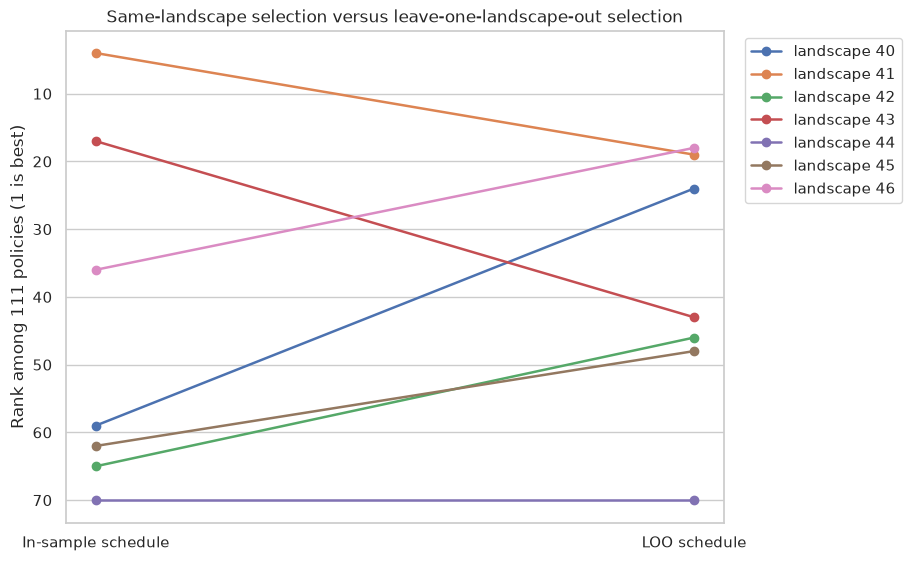

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for row in individual_evaluation.itertuples():
    ax.plot(
        ['In-sample schedule', 'LOO schedule'],
        [row.in_sample_rank, row.loo_heldout_rank],
        marker='o', linewidth=1.8, label=f'landscape {row.landscape}',
    )
ax.invert_yaxis()
ax.set_ylabel(
    f'Rank among {individual_evaluation.policies_ranked.iloc[0]} policies '
    '(1 is best)'
)
ax.set_title('Same-landscape selection versus leave-one-landscape-out selection')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
ax.grid(axis='x', visible=False)
plt.show()

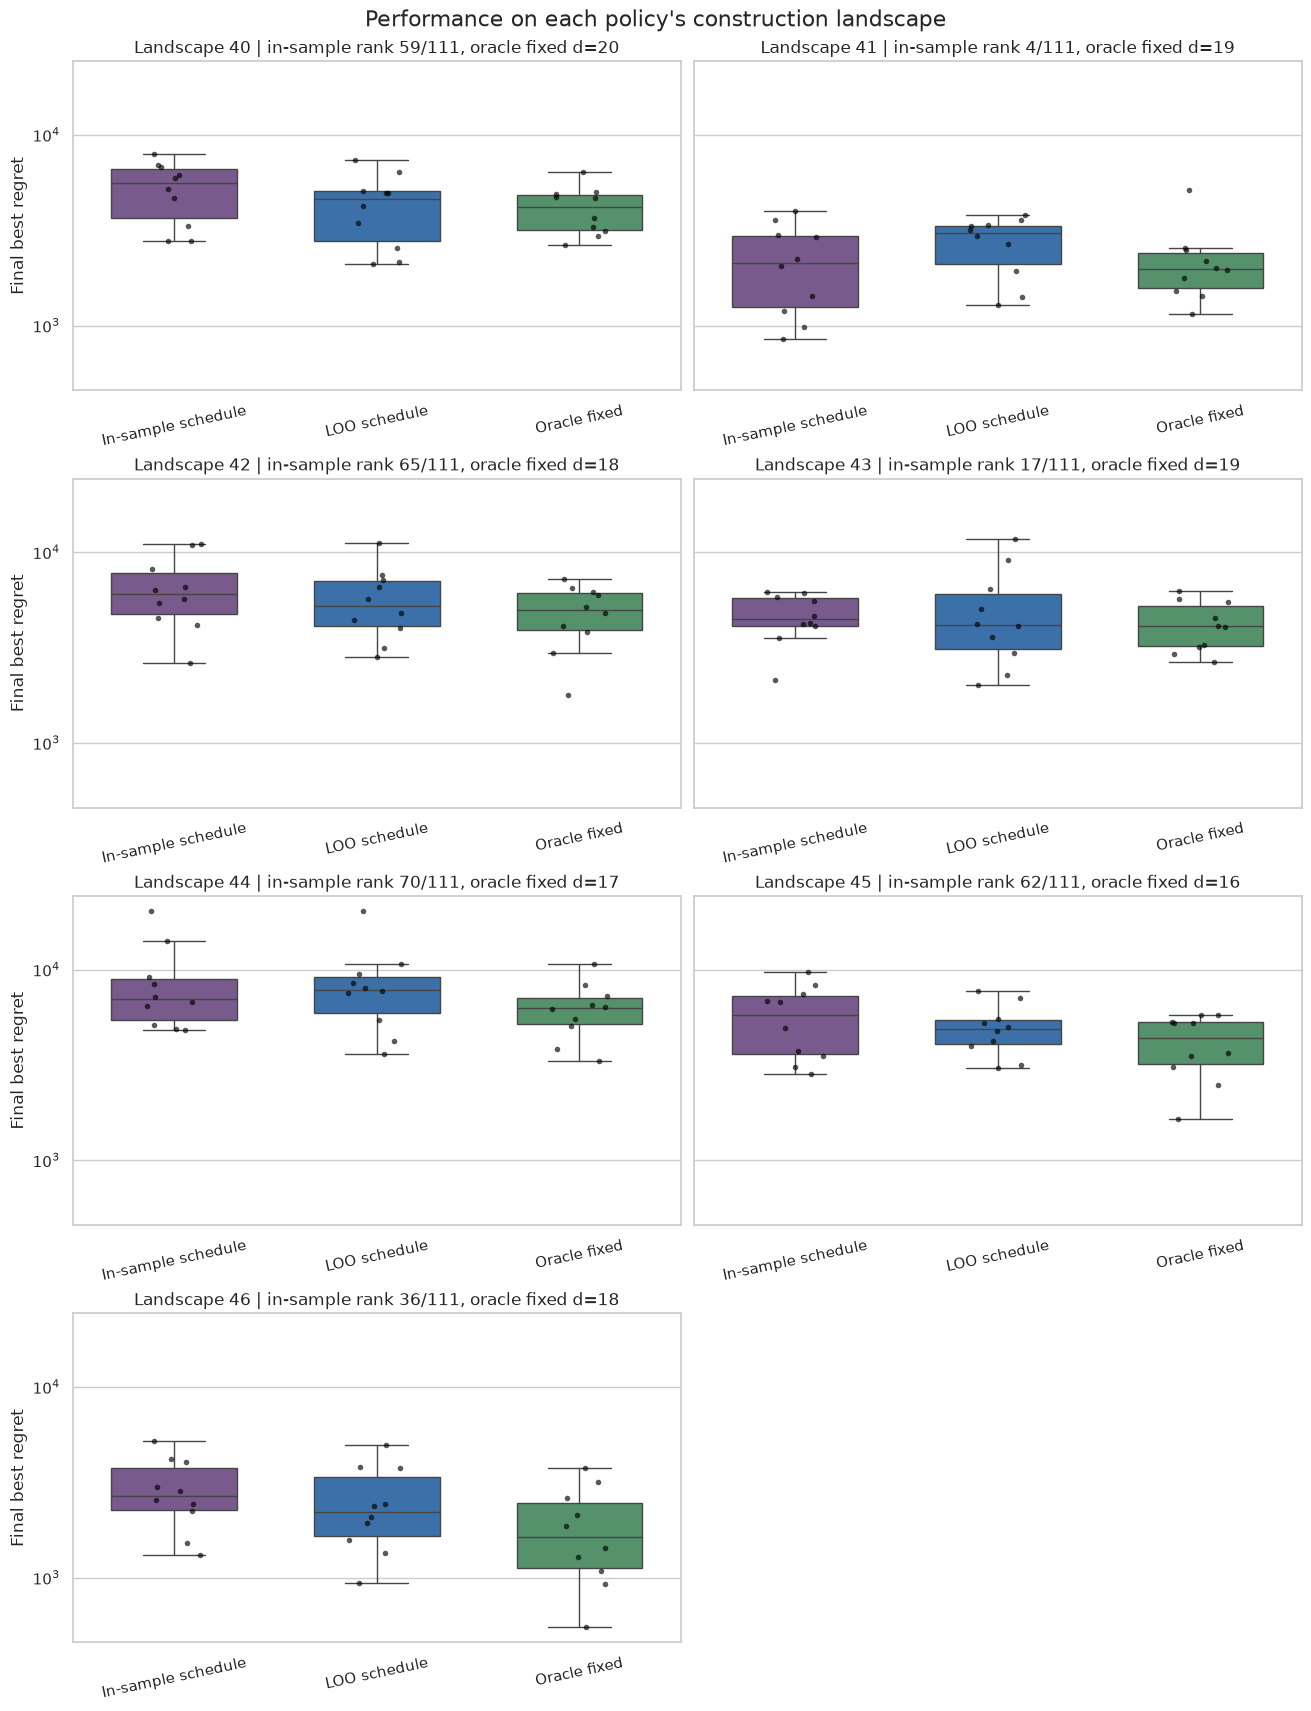

In [15]:
in_sample_component = individual_box_data.query(
    "strategy == 'In-sample schedule'"
)[['landscape', 'strategy', 'smac_seed', 'final_regret']].copy()
in_sample_component['strategy'] = 'In-sample 100-stage'
loo_components = box_data[
    box_data.strategy.isin([
        'Top-1 LOO adaptive', 'Top-3 LOO portfolio',
        'Top-5 LOO portfolio', 'LOO best fixed', 'Oracle fixed',
    ])
].rename(columns={'held_out': 'landscape'})
combined_landscape_box_data = pd.concat(
    [in_sample_component, loo_components], ignore_index=True
)
combined_order = [
    'In-sample 100-stage', 'Top-1 LOO adaptive',
    'Top-3 LOO portfolio', 'Top-5 LOO portfolio',
    'LOO best fixed', 'Oracle fixed',
]
combined_palette = {
    'In-sample 100-stage': '#2a6fbb',
    'Top-1 LOO adaptive': '#6a4c93',
    'Top-3 LOO portfolio': '#d45087',
    'Top-5 LOO portfolio': '#3a9d78',
    'LOO best fixed': '#e28e2c',
    'Oracle fixed': '#4b9b68',
}
expected_strategies = set(combined_order)
for landscape_seed, group in combined_landscape_box_data.groupby('landscape'):
    if set(group.strategy) != expected_strategies or len(group) != 60:
        raise RuntimeError(
            f'Expected six strategies x ten seeds for landscape {landscape_seed}.'
        )
global_y_limits = (
    combined_landscape_box_data.final_regret.min() * 0.8,
    combined_landscape_box_data.final_regret.max() * 1.25,
)

for landscape_seed in BENCHMARK_SEEDS:
    sub = combined_landscape_box_data[
        combined_landscape_box_data.landscape == landscape_seed
    ]
    summary = individual_evaluation[
        individual_evaluation.landscape == landscape_seed
    ].iloc[0]
    fixed_selection = rankings[rankings.held_out == landscape_seed].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 5.3), constrained_layout=True)
    sns.boxplot(
        data=sub, x='strategy', y='final_regret', order=combined_order,
        hue='strategy', hue_order=combined_order, palette=combined_palette,
        width=.62, showfliers=False, legend=False, ax=ax,
    )
    sns.stripplot(
        data=sub, x='strategy', y='final_regret', order=combined_order,
        color='black', alpha=.65, size=4, jitter=.14, ax=ax,
    )
    ax.set_yscale('log')
    ax.set_ylim(global_y_limits)
    ax.set_xlabel('')
    ax.set_ylabel('Final best regret')
    ax.set_title(
        f'Landscape {landscape_seed} | in-sample rank '
        f'{summary.in_sample_rank}/{summary.policies_ranked}, '
        f'LOO fixed d={fixed_selection.loo_best_fixed_depth}, '
        f'oracle fixed d={fixed_selection.oracle_fixed_depth}'
    )
    ax.tick_params(axis='x', rotation=15)
    plt.show()